# EDA — Predicción de churn de cuentas Fudo

Este notebook documenta el análisis que respalda las decisiones de diseño del pipeline.
No es parte del pipeline: sirve para entender los datos y justificar por qué el
etiquetado, el split y las features están hechos como están.

Correr con: `poetry run jupyter lab` (o desde VS Code eligiendo el kernel del `.venv`).

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from churn.config import Config
from churn.data.loader import load_panel
from churn.data.labeling import build_labels, churn_rate_by_period
from churn.pricing.plans import parse_plan

pd.set_option("display.max_columns", 100)
cfg = Config.load("../config/model.yaml")

## 1. El panel: qué hay en el snapshot

In [2]:
panel = load_panel(cfg.path_of("data.raw_path"))
print(f"{len(panel):,} filas · {panel['id'].nunique():,} cuentas · "
      f"{panel['periodo'].nunique()} periodos ({panel['periodo'].min()} a {panel['periodo'].max()})")
panel[["id", "periodo", "plan", "pais", "estado", "usuarios", "productos"]].head()

707,590 filas · 56,202 cuentas · 27 periodos (202401 a 202603)


,id,periodo,plan,pais,estado,usuarios,productos
0,1,202602,pro-idvsls-kds-fi-tbl-ar,Argentina,ACTIVE,96,363
1,52,202401,pr-fi-ar,Argentina,ACTIVE,2,61
2,52,202402,ba-ar,Argentina,ACTIVE,2,61
3,52,202403,ba-ar,Argentina,ACTIVE,2,61
4,52,202404,ba-ar,Argentina,ACTIVE,2,61


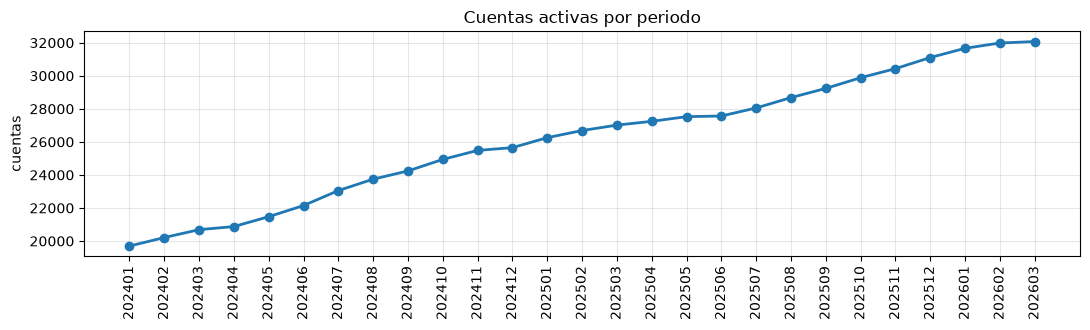

In [3]:
# La base crece de forma sostenida: cualquier metrica en valores absolutos hay que
# leerla contra este crecimiento.
por_periodo = panel.groupby("periodo").size()

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(por_periodo.index.astype(str), por_periodo.values, marker="o", lw=2)
ax.set_title("Cuentas activas por periodo")
ax.set_ylabel("cuentas")
ax.tick_params(axis="x", rotation=90)
ax.grid(alpha=.3)
plt.tight_layout()

In [4]:
# `estado_comercial` es constante: el reporte SOLO trae cuentas ACTIVE.
# Ese sesgo de inclusion es justamente lo que permite inferir el churn.
print(panel["estado_comercial"].value_counts())
print()
print(panel["estado"].value_counts())

estado_comercial
ACTIVE    707590
Name: count, dtype: int64

estado
ACTIVE                  510682
PENDING_PAYMENT         151722
BLOCKING_ALERT           30970
BLOCKED                  14172
PAYMENT_VERIFICATION        44
Name: count, dtype: int64


## 2. Inferir la etiqueta de churn

El churn no viene como columna. Si una cuenta deja de aparecer en el snapshot, dejó de
estar activa. Pero no toda desaparición es una baja: hay cuentas que se ausentan un mes
y vuelven.

In [5]:
# Cuantas cuentas tienen huecos en su historia dentro del panel
presencia = panel.groupby("id")["t"].agg(["min", "max", "nunique"])
presencia["span"] = presencia["max"] - presencia["min"] + 1
presencia["huecos"] = presencia["span"] - presencia["nunique"]

con_huecos = (presencia["huecos"] > 0)
print(f"Cuentas con al menos un hueco: {con_huecos.sum():,} ({con_huecos.mean():.1%})")
presencia["huecos"].value_counts().head(8)

Cuentas con al menos un hueco: 3,727 (6.6%)


huecos
0    52475
1     1149
2      620
3      390
4      271
5      270
6      184
7      165
Name: count, dtype: int64

In [6]:
# De las desapariciones "ingenuas" (ausente en t+1), cuantas son en realidad una pausa
presentes = set(zip(panel["id"], panel["t"]))
ultimo_t = panel["t"].max()

filas = panel[["id", "t"]].drop_duplicates()
filas["desaparece"] = [(i, t + 1) not in presentes for i, t in zip(filas["id"], filas["t"])]
desapariciones = filas[filas["desaparece"] & (filas["t"] < ultimo_t)]

vuelve = [
    any((i, q) in presentes for q in range(t + 2, ultimo_t + 1))
    for i, t in zip(desapariciones["id"], desapariciones["t"])
]
print(f"Desapariciones: {len(desapariciones):,}")
print(f"De esas, reaparecen mas adelante: {np.mean(vuelve):.1%}")
print()
print("-> Por eso el etiquetado exige una ventana de confirmacion de 3 meses:")
print("   un restaurante estacional que vuelve en dos meses no es una baja.")

Desapariciones: 28,966
De esas, reaparecen mas adelante: 16.7%

-> Por eso el etiquetado exige una ventana de confirmacion de 3 meses:
   un restaurante estacional que vuelve en dos meses no es una baja.


Churn base: 3.92% mensual
Es un problema fuertemente desbalanceado: por eso la metrica es PR-AUC y no accuracy.


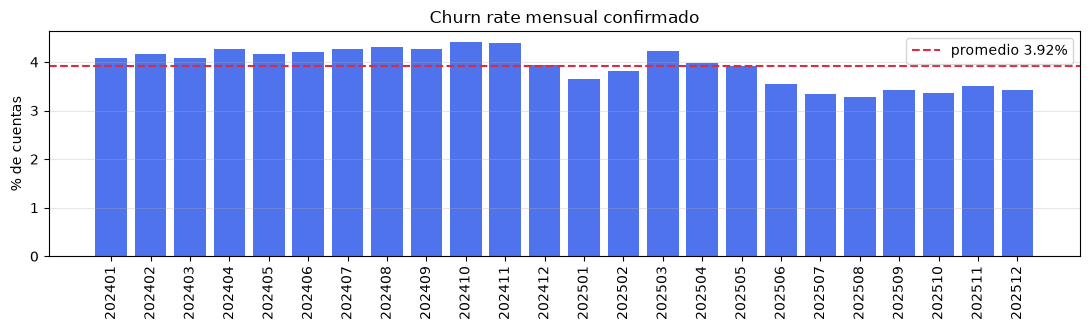

In [7]:
etiquetado = build_labels(panel, confirm_window=3, ambiguous_policy="drop")

tasas = churn_rate_by_period(etiquetado)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(tasas["periodo"].astype(str), tasas["churn_rate"], color="#2f5bea", alpha=.85)
ax.axhline(tasas["churn_rate"].mean(), color="#d92d43", ls="--", lw=1.5,
           label=f"promedio {tasas['churn_rate'].mean():.2f}%")
ax.set_title("Churn rate mensual confirmado")
ax.set_ylabel("% de cuentas")
ax.tick_params(axis="x", rotation=90)
ax.legend()
ax.grid(alpha=.3, axis="y")
plt.tight_layout()

print(f"Churn base: {tasas['churn_rate'].mean():.2f}% mensual")
print("Es un problema fuertemente desbalanceado: por eso la metrica es PR-AUC y no accuracy.")

## 3. Dónde está la señal

Comparación de las métricas entre las cuentas que se dieron de baja y las que no,
en el mes previo a la baja.

In [8]:
etiquetadas = etiquetado[etiquetado["churn"].notna()].copy()

metricas = ["usuarios", "productos", "arqueos", "movimientos_caja", "gastos",
            "fiscal", "descuentos", "cantidad_de_clientes", "ad_pc", "ad_tablet"]

comparacion = etiquetadas.groupby("churn")[metricas].median().T
comparacion.columns = ["se queda", "churnea"]
comparacion["ratio"] = (comparacion["churnea"] / comparacion["se queda"].replace(0, np.nan)).round(2)
comparacion.sort_values("ratio")

,se queda,churnea,ratio
arqueos,19.0,0.0,0.00
descuentos,6.0,0.0,0.00
ad_pc,1064.0,227.0,0.21
cantidad_de_clientes,3.0,1.0,0.33
productos,173.0,98.0,0.57
usuarios,5.0,3.0,0.60
movimientos_caja,0.0,0.0,NaN
gastos,0.0,0.0,NaN
fiscal,0.0,0.0,NaN
ad_tablet,0.0,0.0,NaN


In [9]:
# El estado de cobranza es el separador mas fuerte... y tambien el mas tardio.
tabla = pd.crosstab(etiquetadas["estado"], etiquetadas["churn"], normalize="index") * 100
tabla.columns = ["se queda %", "churnea %"]
tabla.sort_values("churnea %", ascending=False).round(2)

,se queda %,churnea %
estado,,
BLOCKED,66.95,33.05
BLOCKING_ALERT,87.58,12.42
PENDING_PAYMENT,90.72,9.28
ACTIVE,99.11,0.89
PAYMENT_VERIFICATION,100.00,0.00


Cuando una cuenta ya está `BLOCKED`, la baja prácticamente ya ocurrió: predecirla no le
da margen de acción a CX. Por eso el proyecto también mide el modelo **sin ninguna
feature de cobranza**, para saber cuánta señal hay en el comportamiento de uso puro
(PR-AUC 0.294 vs 0.656 con todo).

## 3 bis. Cuentas estacionales

El canvas pide excluir del entrenamiento las cuentas con altas y bajas recurrentes.
Acá se ve de qué tamaño es el fenómeno y qué forma tiene.

In [10]:
from churn.data.seasonality import (
    account_seasonality, find_pause_episodes, monthly_profile, seasonality_by_country,
)

episodios = find_pause_episodes(panel)
print(f"episodios de pausa: {len(episodios):,} sobre {episodios['id'].nunique():,} cuentas "
      f"({episodios['id'].nunique()/panel['id'].nunique():.1%} de la base)")
print(f"duracion mediana: {episodios['duracion'].median():.0f} meses")

por_cuenta = episodios.groupby("id").size()
print(f"\ncuentas que pausaron 2+ veces: {(por_cuenta >= 2).sum():,}")
print(f"reincidencia: {(por_cuenta>=2).mean():.1%} contra un baseline de "
      f"{len(por_cuenta)/panel['id'].nunique():.1%} -> "
      f"x{(por_cuenta>=2).mean()/(len(por_cuenta)/panel['id'].nunique()):.1f}")

episodios de pausa: 4,835 sobre 3,727 cuentas (6.6% de la base)
duracion mediana: 2 meses

cuentas que pausaron 2+ veces: 793
reincidencia: 21.3% contra un baseline de 6.6% -> x3.2


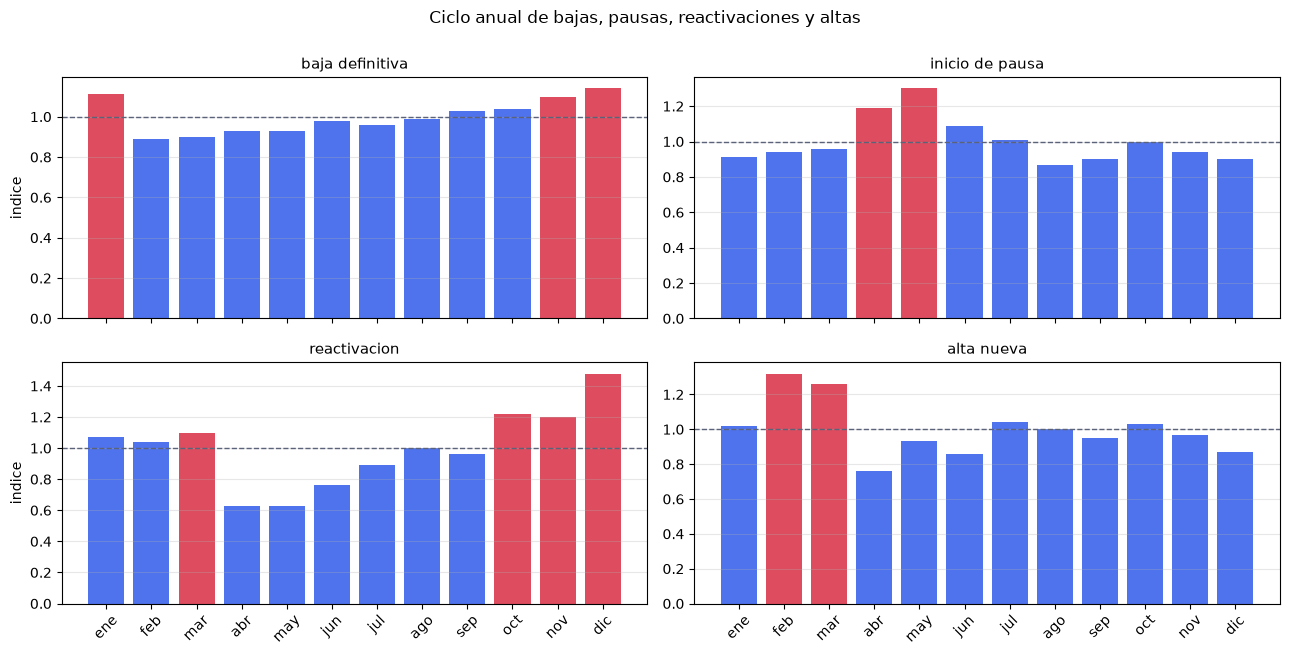

In [11]:
# El ciclo anual: cuando se van, cuando vuelven.
# El indice compara contra un año uniforme (1.00 = lo esperable en ese mes).
ciclo = monthly_profile(panel)

fig, axes = plt.subplots(2, 2, figsize=(13, 6.5), sharex=True)
for ax, evento in zip(axes.ravel(), ciclo["evento"].unique()):
    bloque = ciclo[ciclo["evento"] == evento]
    colores = ["#d92d43" if v >= 1.1 else "#2f5bea" for v in bloque["indice"]]
    ax.bar(range(12), bloque["indice"], color=colores, alpha=.85)
    ax.axhline(1.0, color="#5a6379", ls="--", lw=1)
    ax.set_title(evento, fontsize=11)
    ax.set_xticks(range(12))
    ax.set_xticklabels([m[:3] for m in bloque["mes"]], rotation=45)
    ax.grid(alpha=.3, axis="y")
axes[0,0].set_ylabel("indice"); axes[1,0].set_ylabel("indice")
plt.suptitle("Ciclo anual de bajas, pausas, reactivaciones y altas", y=1.0)
plt.tight_layout()

Las pausas arrancan en **abril-mayo** y las reactivaciones se concentran en
**octubre-diciembre**: es el invierno del hemisferio sur. Las bajas definitivas, en
cambio, son casi planas — no es un fenómeno de calendario.

In [12]:
# Si el patron fuera del producto seria parejo entre paises. Si es del clima, no.
seasonality_by_country(panel)

,pais,cuentas,con_pausa,pct_pausan,pausas_en_temporada_baja_%
0,Chile,16757,1202,7.17,39.6
1,Colombia,5756,401,6.97,34.0
2,Argentina,19602,1293,6.60,41.6
3,Brasil,5385,316,5.87,33.4
4,México,8126,468,5.76,31.8


In [13]:
# Quienes son. El detector separa negocios de temporada de cuentas simplemente erraticas.
perfil_est = account_seasonality(panel)
estacionales = perfil_est[perfil_est["es_estacional"]]
print(estacionales["tipo"].value_counts().to_string())

nombres = panel.groupby("id")["nombre"].last()
paises = panel.groupby("id")["pais"].last()
temporada = estacionales[estacionales["tipo"] == "temporada"].nlargest(12, "duracion_media").copy()
temporada["nombre"] = temporada["id"].map(nombres)
temporada["pais"] = temporada["id"].map(paises)
temporada[["nombre", "pais", "n_pausas", "duracion_media", "mes_baja_modal", "mes_alta_modal"]]

tipo
intermitente    700
temporada       417


,nombre,pais,n_pausas,duracion_media,mes_baja_modal,mes_alta_modal
6,Del Melado al Nevado,Chile,1,8.0,4,12
55,New York Cafe,Chile,1,8.0,5,1
56,Buongiorno,Argentina,1,8.0,7,3
65,Restaurante tonk,Chile,2,8.0,4,1
67,Oscuro Brebaje,México,1,8.0,6,2
127,Nelson Beach,Argentina,2,8.0,4,12
326,oklahomadelivery,Argentina,1,8.0,5,1
369,Bagels&Bagels Pinamar Centro,Argentina,1,8.0,4,12
393,the roxy,Argentina,2,8.0,4,12
476,Tranque viejo,Chile,1,8.0,4,12


Los nombres validan el detector sin necesidad de más análisis: paradores, hoteles y
cervecerías al aire libre, que bajan en abril y vuelven en diciembre.

**Excluirlas del entrenamiento no aporta** (PR-AUC 0.6536 → 0.6480). La razón es que el
ruido que se quería sacar ya lo neutraliza la ventana de confirmación del etiquetado.
El valor de detectarlas está en el scoring: marcar la predicción para que CX sepa que
esa baja puede ser un cierre de temporada y no una pérdida.

## 4. Planes: de dónde sale el revenue

In [14]:
planes = panel["plan"].astype(str)
print(f"{planes.nunique():,} plan codes distintos")

descompuestos = pd.DataFrame([
    {"plan": c, "base": p.base, "modulos": ", ".join(p.modules) or "-",
     "mercado": p.market, "n_modulos": p.n_modules}
    for c, p in ((c, parse_plan(c)) for c in planes.unique())
])
descompuestos["cuentas"] = descompuestos["plan"].map(planes.value_counts())
descompuestos.sort_values("cuentas", ascending=False).head(10)

1,923 plan codes distintos


,plan,base,modulos,mercado,n_modulos,cuentas
17,ba-cl,ba,-,cl,0,53778
2,ba-ar,ba,-,ar,0,29752
5,ba-fi-ar,ba,fi,ar,1,28009
7,st-fi-ar,st,fi,ar,1,19802
18,adv-tbl-cl,adv,tbl,cl,1,18687
11,st-cl,st,-,cl,0,18323
35,ba-dv-cl,ba,dv,cl,1,17812
158,adv-tbl-co,adv,tbl,co,1,12151
8,st-ar,st,-,ar,0,11886
19,ba-mx,ba,-,mx,0,11494


In [15]:
# Los ~2.000 plan codes se reducen a un puñado de piezas combinables:
# eso es lo que hace manejable cargar los precios a mano.
print("Planes base:", sorted(descompuestos["base"].dropna().unique()))
print("Modulos:    ", sorted({m for p in planes.unique() for m in parse_plan(p).modules}))
print("Mercados:   ", sorted(descompuestos["mercado"].dropna().unique()))
print()
n_base = descompuestos["base"].nunique()
n_mods = len({m for p in planes.unique() for m in parse_plan(p).modules})
n_merc = descompuestos["mercado"].nunique()
print(f"-> {n_base} planes + {n_mods} modulos, en {n_merc} mercados")

Planes base: ['adv', 'ba', 'fu', 'ini', 'pr', 'pro', 'st']
Modulos:     ['dv', 'fe', 'fi', 'idvsls', 'kds', 'sbw', 'tbl', 'top']
Mercados:    ['ar', 'br', 'cl', 'co', 'int', 'mx', 'uy']

-> 7 planes + 8 modulos, en 7 mercados


In [16]:
# El churn no es uniforme entre mercados ni entre niveles de plan
etiquetadas["mercado"] = etiquetadas["plan"].map(lambda c: parse_plan(c).market)
etiquetadas["plan_base"] = etiquetadas["plan"].map(lambda c: parse_plan(c).base)

por_mercado = etiquetadas.groupby("mercado")["churn"].agg(cuentas="size", churn_rate="mean")
por_mercado["churn_rate"] = (por_mercado["churn_rate"] * 100).round(2)
por_mercado.sort_values("churn_rate", ascending=False)

,cuentas,churn_rate
mercado,,
br,38991,9.71
mx,79978,4.79
co,55682,4.72
int,4937,4.50
uy,1474,3.66
cl,199996,3.39
ar,228107,2.79


## 5. Conclusiones que se llevaron al pipeline

1. **La etiqueta se deriva de la presencia**, con ventana de confirmación de 3 meses;
   las pausas se descartan del entrenamiento.
2. **Churn base ~3.9% mensual** → problema desbalanceado → métrica PR-AUC, `scale_pos_weight`
   y calibración isotónica de las probabilidades.
3. **Split temporal obligatorio**: la misma cuenta aparece en muchos meses; un split
   aleatorio filtraría el futuro.
4. **Las features tienen que capturar movimiento**, no nivel: deltas, ratios contra el
   promedio móvil y pendientes.
5. **El estado de cobranza domina la señal pero llega tarde**: vale la pena medir el
   modelo con y sin esas features.
6. **La estacionalidad es real y geográfica** (hemisferio sur), pero excluir esas cuentas
   del entrenamiento no mejora el modelo: la ventana de confirmación ya hace ese trabajo.
   El valor está en marcar la predicción para CX.
7. **Los plan codes se descomponen** en plan base + módulos + mercado, lo que reduce
   ~2.000 códigos a 82 precios que se pueden cargar a mano.